# Blunder prediction using pawn-loss engine evaluations

This notebook builds a supervised ML task for the final project:

> Given the current state of a game, predict whether the player to move will
> make a serious mistake/blunder within their next few moves.

This version assumes the engine evaluations are in **pawn units**, not
centipawns.

Examples:

```text
+0.35  = White is better by 0.35 pawns
-1.20  = Black is better by 1.20 pawns
+3.00  = White is better by 3 pawns
```

The target is therefore defined using **pawn loss**, not centipawn loss.

Drop this notebook into:

```text
scratch/blunder_prediction_03_pawn_loss.ipynb
```


## 0. Main controls

For early debugging:

```python
N_GAMES_SAMPLE = 5_000
```

For a realistic baseline:

```python
N_GAMES_SAMPLE = 50_000
```

For the full dataset:

```python
N_GAMES_SAMPLE = None
```

The default thresholds are deliberately in **pawns**:

```python
MISTAKE_PAWN_LOSS = 1.0
BLUNDER_PAWN_LOSS = 2.0
```


In [25]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  ConfusionMatrixDisplay,
  PrecisionRecallDisplay,
  RocCurveDisplay,
  average_precision_score,
  balanced_accuracy_score,
  classification_report,
  confusion_matrix,
  f1_score,
  roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

# Main runtime control. Set to None to use all games.
N_GAMES_SAMPLE = 100_000

# If True, sample random games. If False, take the first N games.
RANDOM_GAME_SAMPLE = True

# Engine evals are assumed to be in pawn units.
MISTAKE_PAWN_LOSS = 1.0
BLUNDER_PAWN_LOSS = 2.0

# Predict whether the player will blunder within this many own moves.
HORIZON_OWN_MOVES = 5

# Clip extreme evals. Useful if mate scores were mapped to large numbers.
MAX_ABS_EVAL_PAWNS = 50.0

pd.set_option("display.max_columns", 120)


## 1. Locate project root and load data


In [26]:
def find_project_root(start=None):
  if start is None:
    start = Path.cwd()

  start = Path(start).resolve()

  for path in [start, *start.parents]:
    has_pyproject = (path / "pyproject.toml").exists()
    has_data = (path / "data").exists()

    if has_pyproject and has_data:
      return path

  raise FileNotFoundError(
    "Could not find project root. Run from the project root "
    "or from a subdirectory such as scratch/."
  )


ROOT = find_project_root()
DATA_DIR = ROOT / "data" / "processed" / "lichess-2017-05-eval-all"

GAMES_PATH = DATA_DIR / "games.parquet"
PLIES_PATH = DATA_DIR / "plies.parquet"
FEATURES_PATH = DATA_DIR / "features.parquet"
DICT_PATH = DATA_DIR / "feature_dictionary.csv"

print(f"Project root: {ROOT}")
print(f"Data dir:     {DATA_DIR}")

for path in [GAMES_PATH, PLIES_PATH, FEATURES_PATH, DICT_PATH]:
  print(f"{path.name:24s} exists={path.exists()}")


Project root: /Users/asudler/Desktop/ucph/coursework/2526-block4/aml/final-project/root/workspace/aidan_sandbox/blunder
Data dir:     /Users/asudler/Desktop/ucph/coursework/2526-block4/aml/final-project/root/workspace/aidan_sandbox/blunder/data/processed/lichess-2017-05-eval-all
games.parquet            exists=True
plies.parquet            exists=True
features.parquet         exists=True
feature_dictionary.csv   exists=True


In [27]:
games = pd.read_parquet(GAMES_PATH)
plies = pd.read_parquet(PLIES_PATH)
features = pd.read_parquet(FEATURES_PATH)

if DICT_PATH.exists():
  feature_dict = pd.read_csv(DICT_PATH)
else:
  feature_dict = pd.DataFrame()

print("games:", games.shape)
print("plies:", plies.shape)
print("features:", features.shape)
print("feature_dict:", feature_dict.shape)


games: (957369, 17)
plies: (61361243, 39)
features: (957369, 80)
feature_dict: (6, 5)


## 2. Inspect schema and detect columns

If auto-detection guesses incorrectly, fill in `COLUMN_OVERRIDES`.


In [28]:
print("games columns")
display(pd.DataFrame({"column": games.columns}))

print("plies columns")
display(pd.DataFrame({"column": plies.columns}))

print("features columns")
display(pd.DataFrame({"column": features.columns}))


games columns


,column
0,game_index
1,event
2,site
3,white
4,black
5,result
6,result_white
7,white_elo
8,black_elo
9,avg_elo


plies columns


,column
0,game_index
1,ply
2,move_number
3,side
4,san_raw
5,comment_raw
6,eval_raw
7,eval_pawns
8,is_mate_eval
9,mate_distance


features columns


,column
0,game_index
1,n_plies
2,n_eval_available
3,frac_eval_available
4,n_missing_eval
...,...
75,opening
76,time_control
77,time_base_seconds
78,time_increment_seconds


In [29]:
if len(feature_dict) > 0:
  display(feature_dict.head(80))


,table,column,meaning,raw_or_derived,unit
0,plies,eval_pawns,Engine eval from White's perspective in pawn u...,raw-parsed,pawns
1,plies,eval_proxy,Finite mate-aware numeric eval used for summar...,derived,pawns proxy
2,plies,phase_progress,Fraction of starting non-pawn material removed.,derived,unitless
3,features,mean_abs_eval_change,Mean absolute change in eval_proxy per ply.,derived,pawns proxy
4,features,white_mean_loss_proxy,Mean eval loss after White moves.,derived,pawns proxy
5,features,black_mean_loss_proxy,Mean eval loss after Black moves.,derived,pawns proxy


In [30]:
COLUMN_OVERRIDES = {
  # Fill these in only if auto-detection guesses wrong.
  #
  # Examples:
  # "game_id": "game_id",
  # "ply_index": "ply_index",
  # "eval_pawns": "eval",
  # "turn": "turn",
}


In [31]:
def pick_column(df, candidates, required=True, role="column"):
  for key in candidates:
    if key in COLUMN_OVERRIDES:
      override = COLUMN_OVERRIDES[key]
      if override in df.columns:
        return override

  for name in candidates:
    if name in df.columns:
      return name

  if required:
    cols = ", ".join(candidates)
    raise KeyError(f"Could not find {role}. Tried: {cols}")

  return None


def pick_contains(df, include, exclude=None, required=True, role="column"):
  if exclude is None:
    exclude = []

  include = [x.lower() for x in include]
  exclude = [x.lower() for x in exclude]

  matches = []
  for col in df.columns:
    low = col.lower()
    has_all = all(x in low for x in include)
    has_excl = any(x in low for x in exclude)
    if has_all and not has_excl:
      matches.append(col)

  if matches:
    return matches[0]

  if required:
    raise KeyError(f"Could not find {role} containing {include}")

  return None


game_id_col = pick_column(
  plies,
  ["game_id", "game_index", "game_idx", "id"],
  role="game id column",
)

ply_col = pick_column(
  plies,
  ["ply", "ply_index", "ply_number", "move_ply"],
  role="ply index column",
)

eval_col = pick_column(
  plies,
  [
    "eval_pawns",
    "eval",
    "score",
    "engine_eval",
    "stockfish_eval",
    "stockfish_eval_pawns",
  ],
  required=False,
  role="engine eval pawn column",
)

if eval_col is None:
  eval_col = pick_contains(
    plies,
    ["eval"],
    exclude=["mate", "raw", "comment"],
    role="engine eval pawn column",
  )

turn_col = pick_column(
  plies,
  ["turn", "side", "color", "player_color", "mover"],
  required=False,
  role="side-to-move column",
)

print("Detected columns")
print("game_id_col:", game_id_col)
print("ply_col:    ", ply_col)
print("eval_col:   ", eval_col)
print("turn_col:   ", turn_col)


Detected columns
game_id_col: game_index
ply_col:     ply
eval_col:    eval_pawns
turn_col:    side


## 3. Sample complete games early

Sampling by game keeps the data internally consistent while making iteration
much faster.


In [32]:
def sample_games(df, n_games, random_sample=True, seed=RANDOM_STATE):
  if n_games is None:
    return df.copy()

  game_ids = df[game_id_col].drop_duplicates()

  if n_games >= len(game_ids):
    return df.copy()

  if random_sample:
    selected_ids = game_ids.sample(n_games, random_state=seed)
  else:
    selected_ids = game_ids.head(n_games)

  sampled = df[df[game_id_col].isin(selected_ids)].copy()
  sampled = sampled.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  return sampled


plies = sample_games(
  plies,
  N_GAMES_SAMPLE,
  random_sample=RANDOM_GAME_SAMPLE,
)

sampled_game_ids = set(plies[game_id_col].drop_duplicates())

if game_id_col in games.columns:
  games = games[games[game_id_col].isin(sampled_game_ids)].copy()

if game_id_col in features.columns:
  features = features[features[game_id_col].isin(sampled_game_ids)].copy()

print("After sampling")
print("games:", games.shape)
print("plies:", plies.shape)
print("features:", features.shape)
print("unique games in plies:", plies[game_id_col].nunique())


After sampling
games: (100000, 17)
plies: (6410571, 39)
features: (100000, 80)
unique games in plies: 100000


## 4. Build pawn-loss blunder labels

Assumption:

- `eval_pawns` is from White's perspective.
- Positive eval means White is better.
- Negative eval means Black is better.

For the player who just moved:

- White loss = `eval_before - eval_after`
- Black loss = `eval_after - eval_before`

In both cases, larger positive `pawn_loss` means the mover made the position
worse for themselves.


In [33]:
def normalize_turn_value(x):
  if pd.isna(x):
    return np.nan

  value = str(x).strip().lower()

  if value in {"w", "white", "1", "true"}:
    return "white"

  if value in {"b", "black", "0", "false"}:
    return "black"

  return value


def add_basic_ply_columns(df):
  df = df.copy()
  df = df.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  df["eval_pawns"] = pd.to_numeric(df[eval_col], errors="coerce")
  df["eval_pawns"] = df["eval_pawns"].clip(
    -MAX_ABS_EVAL_PAWNS,
    MAX_ABS_EVAL_PAWNS,
  )

  if turn_col is not None:
    df["side_to_move"] = df[turn_col].map(normalize_turn_value)
  else:
    df["side_to_move"] = np.where(df[ply_col] % 2 == 1, "white", "black")

  # In this processed dataset, each ply row is assumed to represent the move
  # made by side_to_move at that ply.
  df["mover"] = df["side_to_move"]

  df["ply_number"] = pd.to_numeric(df[ply_col], errors="coerce")
  df["fullmove_number"] = ((df["ply_number"] + 1) // 2).astype("Int64")

  return df


def add_pawn_loss_labels(df):
  df = df.copy()
  group = df.groupby(game_id_col, sort=False)

  df["eval_after_pawns"] = group["eval_pawns"].shift(-1)
  df["eval_delta_pawns"] = df["eval_after_pawns"] - df["eval_pawns"]

  white_loss = -df["eval_delta_pawns"]
  black_loss = df["eval_delta_pawns"]

  df["pawn_loss"] = np.where(
    df["mover"].eq("white"),
    white_loss,
    black_loss,
  )

  df["pawn_loss"] = df["pawn_loss"].clip(lower=0)

  df["is_mistake"] = (
    df["pawn_loss"].ge(MISTAKE_PAWN_LOSS).astype(int)
  )

  df["is_blunder"] = (
    df["pawn_loss"].ge(BLUNDER_PAWN_LOSS).astype(int)
  )

  return df


plies_ml = add_basic_ply_columns(plies)
plies_ml = add_pawn_loss_labels(plies_ml)

display(plies_ml[
  [
    game_id_col,
    ply_col,
    "mover",
    "eval_pawns",
    "eval_after_pawns",
    "eval_delta_pawns",
    "pawn_loss",
    "is_blunder",
  ]
].head(20))


,game_index,ply,mover,eval_pawns,eval_after_pawns,eval_delta_pawns,pawn_loss,is_blunder
0,209,1,white,0.14,0.26,0.12,0.00,0
1,209,2,black,0.26,0.23,-0.03,0.00,0
2,209,3,white,0.23,0.36,0.13,0.00,0
3,209,4,black,0.36,0.25,-0.11,0.00,0
4,209,5,white,0.25,0.28,0.03,0.00,0
5,209,6,black,0.28,0.14,-0.14,0.00,0
6,209,7,white,0.14,0.12,-0.02,0.02,0
7,209,8,black,0.12,-0.11,-0.23,0.00,0
8,209,9,white,-0.11,-0.09,0.02,0.00,0
9,209,10,black,-0.09,-0.11,-0.02,0.00,0


## 5. Sanity-check the pawn-loss scale

The fractions below should be nonzero and plausible.

If the blunder fraction is still nearly zero, either:

1. the side/mover convention is wrong, or
2. the threshold is still too strict, or
3. the eval column is not the column we think it is.


In [34]:
print("Eval summary")
display(plies_ml["eval_pawns"].describe(percentiles=[
  0.01,
  0.05,
  0.25,
  0.5,
  0.75,
  0.95,
  0.99,
]))

print("Pawn-loss summary")
display(plies_ml["pawn_loss"].describe(percentiles=[
  0.5,
  0.75,
  0.9,
  0.95,
  0.99,
  0.999,
]))

print("Move-level mistake/blunder fractions")
display(plies_ml[["is_mistake", "is_blunder"]].mean().to_frame("fraction"))

print("Largest pawn losses")
display(
  plies_ml[
    [
      game_id_col,
      ply_col,
      "mover",
      "eval_pawns",
      "eval_after_pawns",
      "pawn_loss",
    ]
  ]
  .sort_values("pawn_loss", ascending=False)
  .head(20)
)


Eval summary


count    5.882628e+06
mean     1.383848e-01
std      7.105141e+00
min     -5.000000e+01
1%      -1.902000e+01
5%      -8.130000e+00
25%     -8.900000e-01
50%      1.500000e-01
75%      1.150000e+00
95%      8.370000e+00
99%      1.935000e+01
max      5.000000e+01
Name: eval_pawns, dtype: float64

Pawn-loss summary


count    5.733555e+06
mean     2.365033e-02
std      4.979375e-01
min     -0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      3.000000e-02
95%      8.000000e-02
99%      2.400000e-01
99.9%    1.870000e+00
max      4.599000e+01
Name: pawn_loss, dtype: float64

Move-level mistake/blunder fractions


,fraction
is_mistake,0.001614
is_blunder,0.000850


Largest pawn losses


,game_index,ply,mover,eval_pawns,eval_after_pawns,pawn_loss
5641014,10247871,189,white,-1.11,-47.10,45.99
561390,981815,111,white,50.00,5.53,44.47
1257892,2222177,137,white,50.00,5.91,44.09
1962886,3468259,115,white,50.00,5.91,44.09
5095052,9229984,103,white,50.00,6.29,43.71
1586789,2801110,87,white,50.00,6.47,43.53
2297353,4076654,139,white,50.00,6.57,43.43
3637906,6558105,107,white,50.00,6.64,43.36
4028053,7275081,126,black,-50.00,-6.71,43.29
566350,989180,65,white,50.00,7.21,42.79


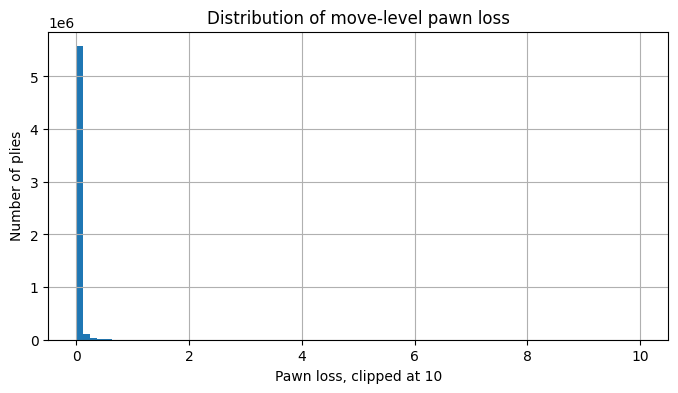

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))
plies_ml["pawn_loss"].clip(0, 10).hist(bins=80, ax=ax)
ax.set_xlabel("Pawn loss, clipped at 10")
ax.set_ylabel("Number of plies")
ax.set_title("Distribution of move-level pawn loss")
plt.show()


## 6. Fast future-blunder target

This target asks:

> Does the same player blunder within their next `HORIZON_OWN_MOVES` moves?

It groups by `(game_id, mover)` and shifts within each player's own move
sequence.


In [36]:
def add_future_blunder_target_fast(df, horizon_own_moves):
  df = df.copy()
  df = df.sort_values([game_id_col, "mover", ply_col])

  keys = [game_id_col, "mover"]
  group = df.groupby(keys, sort=False)["is_blunder"]

  future_count = pd.Series(0, index=df.index, dtype=float)

  for step in range(1, horizon_own_moves + 1):
    future_count += group.shift(-step).fillna(0)

  df["future_blunder_count"] = future_count
  df["will_blunder_soon"] = (
    df["future_blunder_count"].gt(0).astype(int)
  )

  df = df.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  return df


plies_ml = add_future_blunder_target_fast(
  plies_ml,
  HORIZON_OWN_MOVES,
)

print("Future-blunder target counts")
display(plies_ml["will_blunder_soon"].value_counts(dropna=False))
display(plies_ml["will_blunder_soon"].value_counts(
  normalize=True,
  dropna=False,
))

game_target = (
  pd.DataFrame({
    "game_id": plies_ml[game_id_col],
    "target": plies_ml["will_blunder_soon"],
  })
  .groupby("game_id")["target"]
  .max()
)

print("Games with at least one positive target")
display(game_target.value_counts(dropna=False))
display(game_target.value_counts(normalize=True, dropna=False))


Future-blunder target counts


will_blunder_soon
0    6384552
1      26019
Name: count, dtype: int64

will_blunder_soon
0    0.995941
1    0.004059
Name: proportion, dtype: float64

Games with at least one positive target


target
0    95195
1     4805
Name: count, dtype: int64

target
0    0.95195
1    0.04805
Name: proportion, dtype: float64

## 7. Create legal pre-blunder features

These features use only information available up to the current position.

Leakage columns intentionally excluded:

- `eval_after_pawns`
- `eval_delta_pawns`
- `pawn_loss`
- `is_mistake`
- `is_blunder`
- `future_blunder_count`
- `will_blunder_soon`


In [37]:
def add_rolling_features(df):
  df = df.copy()
  df = df.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  group = df.groupby(game_id_col, sort=False)

  df["abs_eval_pawns"] = df["eval_pawns"].abs()
  df["eval_sign"] = np.sign(df["eval_pawns"]).astype(float)

  df["eval_prev_1"] = group["eval_pawns"].shift(1)
  df["eval_prev_2"] = group["eval_pawns"].shift(2)
  df["eval_prev_4"] = group["eval_pawns"].shift(4)

  df["eval_change_prev_1"] = df["eval_pawns"] - df["eval_prev_1"]
  df["eval_change_prev_2"] = df["eval_pawns"] - df["eval_prev_2"]
  df["eval_change_prev_4"] = df["eval_pawns"] - df["eval_prev_4"]

  df["abs_eval_change_prev_1"] = df["eval_change_prev_1"].abs()
  df["abs_eval_change_prev_2"] = df["eval_change_prev_2"].abs()
  df["abs_eval_change_prev_4"] = df["eval_change_prev_4"].abs()

  df["game_ply_fraction"] = group.cumcount()
  max_ply = group["game_ply_fraction"].transform("max").replace(0, np.nan)
  df["game_ply_fraction"] = df["game_ply_fraction"] / max_ply

  df["phase"] = pd.cut(
    df["fullmove_number"].astype(float),
    bins=[0, 10, 25, 10_000],
    labels=["opening", "middlegame", "endgame"],
    include_lowest=True,
  )

  return df


def add_player_history_features(df):
  df = df.copy()
  df = df.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  keys = [game_id_col, "mover"]
  group = df.groupby(keys, sort=False)

  prev_blunder = group["is_blunder"].shift(1).fillna(0)
  prev_mistake = group["is_mistake"].shift(1).fillna(0)
  prev_pawn_loss = group["pawn_loss"].shift(1)

  hist_keys = [df[game_id_col], df["mover"]]

  df["prev_own_blunders"] = (
    prev_blunder
    .groupby(hist_keys, sort=False)
    .cumsum()
  )

  df["prev_own_mistakes"] = (
    prev_mistake
    .groupby(hist_keys, sort=False)
    .cumsum()
  )

  df["prev_own_pawn_loss"] = prev_pawn_loss

  for window in [3, 5, 10]:
    shifted_loss = group["pawn_loss"].shift(1)

    rolled = (
      shifted_loss
      .groupby(hist_keys, sort=False)
      .rolling(window, min_periods=1)
      .mean()
    )

    df[f"prev_own_pawn_loss_mean_{window}"] = (
      rolled.reset_index(level=[0, 1], drop=True)
    )

  return df


plies_ml = add_rolling_features(plies_ml)
plies_ml = add_player_history_features(plies_ml)


In [38]:
candidate_features = [
  "eval_pawns",
  "abs_eval_pawns",
  "eval_sign",
  "fullmove_number",
  "game_ply_fraction",
  "eval_prev_1",
  "eval_prev_2",
  "eval_prev_4",
  "eval_change_prev_1",
  "eval_change_prev_2",
  "eval_change_prev_4",
  "abs_eval_change_prev_1",
  "abs_eval_change_prev_2",
  "abs_eval_change_prev_4",
  "prev_own_blunders",
  "prev_own_mistakes",
  "prev_own_pawn_loss",
  "prev_own_pawn_loss_mean_3",
  "prev_own_pawn_loss_mean_5",
  "prev_own_pawn_loss_mean_10",
  "mover",
  "phase",
]

feature_cols = [c for c in candidate_features if c in plies_ml.columns]

print("Feature columns:")
for col in feature_cols:
  print(" ", col)


Feature columns:
  eval_pawns
  abs_eval_pawns
  eval_sign
  fullmove_number
  game_ply_fraction
  eval_prev_1
  eval_prev_2
  eval_prev_4
  eval_change_prev_1
  eval_change_prev_2
  eval_change_prev_4
  abs_eval_change_prev_1
  abs_eval_change_prev_2
  abs_eval_change_prev_4
  prev_own_blunders
  prev_own_mistakes
  prev_own_pawn_loss
  prev_own_pawn_loss_mean_3
  prev_own_pawn_loss_mean_5
  prev_own_pawn_loss_mean_10
  mover
  phase


In [39]:
model_df = plies_ml.dropna(subset=["will_blunder_soon"]).copy()

# Remove last plies where the full future horizon cannot exist.
group = model_df.groupby(game_id_col, sort=False)
max_ply = group[ply_col].transform("max")
min_future_gap = 2 * HORIZON_OWN_MOVES
model_df = model_df[model_df[ply_col] <= max_ply - min_future_gap].copy()

X = model_df[feature_cols]
y = model_df["will_blunder_soon"].astype(int)
groups = model_df[game_id_col]

print("Model rows:", len(model_df))
print("Unique games:", groups.nunique())
print("Positive target rate:", y.mean())

print("Target counts")
display(y.value_counts(dropna=False))
display(y.value_counts(normalize=True, dropna=False))

display(X.head())


Model rows: 5410769
Unique games: 99889
Positive target rate: 0.004220656989792024
Target counts


will_blunder_soon
0    5387932
1      22837
Name: count, dtype: int64

will_blunder_soon
0    0.995779
1    0.004221
Name: proportion, dtype: float64

,eval_pawns,abs_eval_pawns,eval_sign,fullmove_number,game_ply_fraction,eval_prev_1,eval_prev_2,eval_prev_4,eval_change_prev_1,eval_change_prev_2,eval_change_prev_4,abs_eval_change_prev_1,abs_eval_change_prev_2,abs_eval_change_prev_4,prev_own_blunders,prev_own_mistakes,prev_own_pawn_loss,prev_own_pawn_loss_mean_3,prev_own_pawn_loss_mean_5,prev_own_pawn_loss_mean_10,mover,phase
0,0.14,0.14,1.0,1,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,white,opening
1,0.26,0.26,1.0,1,0.030303,0.14,NaN,NaN,0.12,NaN,NaN,0.12,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,black,opening
2,0.23,0.23,1.0,2,0.060606,0.26,0.14,NaN,-0.03,0.09,NaN,0.03,0.09,NaN,0.0,0.0,0.0,0.0,0.0,0.0,white,opening
3,0.36,0.36,1.0,2,0.090909,0.23,0.26,NaN,0.13,0.10,NaN,0.13,0.10,NaN,0.0,0.0,0.0,0.0,0.0,0.0,black,opening
4,0.25,0.25,1.0,3,0.121212,0.36,0.23,0.14,-0.11,0.02,0.11,0.11,0.02,0.11,0.0,0.0,0.0,0.0,0.0,0.0,white,opening


## 8. Stratified train/validation/test split by game

We must keep entire games together, but we also need each split to contain
positive examples.

This split stratifies at the game level using:

```text
game target = max(will_blunder_soon within game)
```


In [40]:
def stratified_game_train_valid_test_split(
  X,
  y,
  groups,
  seed=RANDOM_STATE,
):
  game_df = (
    pd.DataFrame({
      "game_id": groups,
      "target": y,
    })
    .groupby("game_id", as_index=False)["target"]
    .max()
  )

  if game_df["target"].nunique() < 2:
    raise ValueError(
      "Only one game-level target class exists. Lower "
      "BLUNDER_PAWN_LOSS or increase N_GAMES_SAMPLE."
    )

  train_games, temp_games = train_test_split(
    game_df,
    train_size=0.70,
    random_state=seed,
    stratify=game_df["target"],
  )

  valid_games, test_games = train_test_split(
    temp_games,
    train_size=0.50,
    random_state=seed,
    stratify=temp_games["target"],
  )

  train_ids = set(train_games["game_id"])
  valid_ids = set(valid_games["game_id"])
  test_ids = set(test_games["game_id"])

  train_mask = groups.isin(train_ids)
  valid_mask = groups.isin(valid_ids)
  test_mask = groups.isin(test_ids)

  X_train = X.loc[train_mask]
  y_train = y.loc[train_mask]
  g_train = groups.loc[train_mask]

  X_valid = X.loc[valid_mask]
  y_valid = y.loc[valid_mask]
  g_valid = groups.loc[valid_mask]

  X_test = X.loc[test_mask]
  y_test = y.loc[test_mask]
  g_test = groups.loc[test_mask]

  for split_name, split_y in [
    ("train", y_train),
    ("valid", y_valid),
    ("test", y_test),
  ]:
    if split_y.nunique() < 2:
      raise ValueError(
        f"{split_name} has only one row-level target class. "
        "Increase N_GAMES_SAMPLE or lower BLUNDER_PAWN_LOSS."
      )

  return (
    X_train,
    X_valid,
    X_test,
    y_train,
    y_valid,
    y_test,
    g_train,
    g_valid,
    g_test,
  )


split = stratified_game_train_valid_test_split(X, y, groups)

(
  X_train,
  X_valid,
  X_test,
  y_train,
  y_valid,
  y_test,
  g_train,
  g_valid,
  g_test,
) = split

print("train:", X_train.shape, y_train.mean(), g_train.nunique())
print("valid:", X_valid.shape, y_valid.mean(), g_valid.nunique())
print("test: ", X_test.shape, y_test.mean(), g_test.nunique())

print("\nTrain target counts")
display(y_train.value_counts())

print("\nValid target counts")
display(y_valid.value_counts())

print("\nTest target counts")
display(y_test.value_counts())


train: (3788377, 22) 0.004228987769696628 69922
valid: (813312, 22) 0.004141092225369846 14983
test:  (809080, 22) 0.004261630493894299 14984

Train target counts


will_blunder_soon
0    3772356
1      16021
Name: count, dtype: int64


Valid target counts


will_blunder_soon
0    809944
1      3368
Name: count, dtype: int64


Test target counts


will_blunder_soon
0    805632
1      3448
Name: count, dtype: int64

## 9. Preprocessing and baseline models

We compare:

1. Dummy baseline.
2. Logistic regression.
3. Histogram gradient boosting.


In [41]:
numeric_cols = [
  c for c in feature_cols
  if pd.api.types.is_numeric_dtype(X_train[c])
]

categorical_cols = [
  c for c in feature_cols
  if c not in numeric_cols
]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

numeric_preprocess = Pipeline([
  ("imputer", SimpleImputer(strategy="median")),
  ("scaler", StandardScaler()),
])

categorical_preprocess = Pipeline([
  ("imputer", SimpleImputer(strategy="most_frequent")),
  ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess_linear = ColumnTransformer([
  ("num", numeric_preprocess, numeric_cols),
  ("cat", categorical_preprocess, categorical_cols),
])

preprocess_tree = ColumnTransformer([
  ("num", SimpleImputer(strategy="median"), numeric_cols),
  ("cat", categorical_preprocess, categorical_cols),
])


Numeric columns: ['eval_pawns', 'abs_eval_pawns', 'eval_sign', 'fullmove_number', 'game_ply_fraction', 'eval_prev_1', 'eval_prev_2', 'eval_prev_4', 'eval_change_prev_1', 'eval_change_prev_2', 'eval_change_prev_4', 'abs_eval_change_prev_1', 'abs_eval_change_prev_2', 'abs_eval_change_prev_4', 'prev_own_blunders', 'prev_own_mistakes', 'prev_own_pawn_loss', 'prev_own_pawn_loss_mean_3', 'prev_own_pawn_loss_mean_5', 'prev_own_pawn_loss_mean_10']
Categorical columns: ['mover', 'phase']


In [42]:
models = {
  "dummy": Pipeline([
    ("preprocess", preprocess_tree),
    ("model", DummyClassifier(strategy="prior")),
  ]),
  "logreg": Pipeline([
    ("preprocess", preprocess_linear),
    ("model", LogisticRegression(
      max_iter=1000,
      class_weight="balanced",
      random_state=RANDOM_STATE,
    )),
  ]),
  "hist_gbdt": Pipeline([
    ("preprocess", preprocess_tree),
    ("model", HistGradientBoostingClassifier(
      learning_rate=0.06,
      max_leaf_nodes=31,
      l2_regularization=0.1,
      random_state=RANDOM_STATE,
    )),
  ]),
}


In [43]:
def get_score(model, X_eval):
  if hasattr(model, "predict_proba"):
    proba = model.predict_proba(X_eval)

    if proba.shape[1] == 1:
      only_class = model.classes_[0]
      if only_class == 1:
        return np.ones(len(X_eval))
      return np.zeros(len(X_eval))

    positive_index = list(model.classes_).index(1)
    return proba[:, positive_index]

  if hasattr(model, "decision_function"):
    score = model.decision_function(X_eval)
    return 1 / (1 + np.exp(-score))

  return model.predict(X_eval)


def evaluate_model(name, model, X_eval, y_eval, threshold=0.5):
  score = get_score(model, X_eval)
  pred = (score >= threshold).astype(int)

  out = {
    "model": name,
    "roc_auc": roc_auc_score(y_eval, score),
    "avg_precision": average_precision_score(y_eval, score),
    "balanced_acc": balanced_accuracy_score(y_eval, pred),
    "f1": f1_score(y_eval, pred),
    "positive_rate_pred": pred.mean(),
  }

  return out


if y_train.nunique() < 2:
  raise ValueError("Training target has only one class.")

if y_valid.nunique() < 2:
  raise ValueError("Validation target has only one class.")

results = []

for name, model in models.items():
  print(f"Training {name}...")
  model.fit(X_train, y_train)
  row = evaluate_model(name, model, X_valid, y_valid)
  results.append(row)

results_df = pd.DataFrame(results).sort_values(
  "avg_precision",
  ascending=False,
)

display(results_df)


Training dummy...
Training logreg...
Training hist_gbdt...


,model,roc_auc,avg_precision,balanced_acc,f1,positive_rate_pred
2,hist_gbdt,0.923369,0.055815,0.500000,0.000000,0.000000
1,logreg,0.877750,0.027582,0.800217,0.027814,0.247659
0,dummy,0.500000,0.004141,0.500000,0.000000,0.000000


## 10. Choose threshold on validation set

For rare-event prediction, threshold `0.5` is often too conservative.


Best validation model: hist_gbdt


,threshold,f1,balanced_acc,pred_positive_rate
5,0.06,0.116488,0.613413,0.012831
4,0.05,0.115837,0.643816,0.017597
3,0.04,0.114755,0.682856,0.023867
6,0.07,0.113415,0.586373,0.009085
7,0.08,0.105673,0.563630,0.006284
2,0.03,0.105596,0.724499,0.033562
8,0.09,0.099074,0.550303,0.004621
9,0.10,0.092190,0.541155,0.003541
1,0.02,0.090549,0.771466,0.049875
10,0.11,0.082271,0.532780,0.002704


Selected threshold: 0.060000000000000005


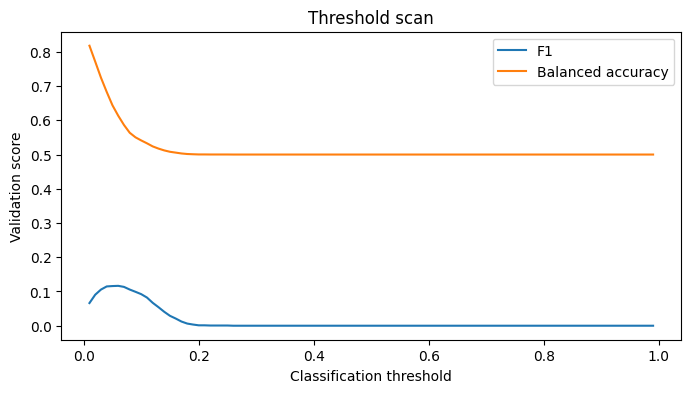

In [44]:
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

print("Best validation model:", best_model_name)

valid_score = get_score(best_model, X_valid)

threshold_rows = []
for threshold in np.linspace(0.01, 0.99, 99):
  pred = (valid_score >= threshold).astype(int)
  threshold_rows.append({
    "threshold": threshold,
    "f1": f1_score(y_valid, pred),
    "balanced_acc": balanced_accuracy_score(y_valid, pred),
    "pred_positive_rate": pred.mean(),
  })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold = threshold_df.sort_values("f1", ascending=False).iloc[0]

display(threshold_df.sort_values("f1", ascending=False).head(10))
print("Selected threshold:", best_threshold["threshold"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
ax.plot(
  threshold_df["threshold"],
  threshold_df["balanced_acc"],
  label="Balanced accuracy",
)
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Validation score")
ax.set_title("Threshold scan")
ax.legend()
plt.show()


## 11. Final test-set evaluation


In [45]:
threshold = float(best_threshold["threshold"])

test_score = get_score(best_model, X_test)
test_pred = (test_score >= threshold).astype(int)

print("Test metrics")
print("ROC AUC:", roc_auc_score(y_test, test_score))
print("Average precision:", average_precision_score(y_test, test_score))
print("Balanced accuracy:", balanced_accuracy_score(y_test, test_pred))
print("F1:", f1_score(y_test, test_pred))
print()
print(classification_report(y_test, test_pred, digits=4))


Test metrics
ROC AUC: 0.9197421964552267
Average precision: 0.05763513653853238
Balanced accuracy: 0.6070254373825439
F1: 0.1147408008258978

              precision    recall  f1-score   support

           0     0.9967    0.9884    0.9925    805632
           1     0.0769    0.2256    0.1147      3448

    accuracy                         0.9852    809080
   macro avg     0.5368    0.6070    0.5536    809080
weighted avg     0.9927    0.9852    0.9888    809080



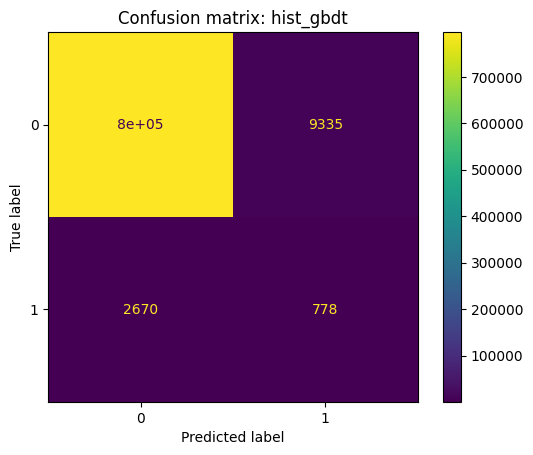

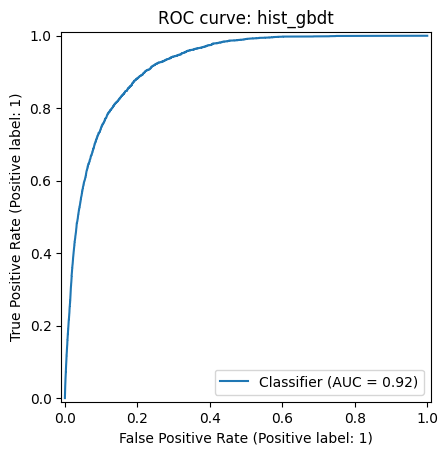

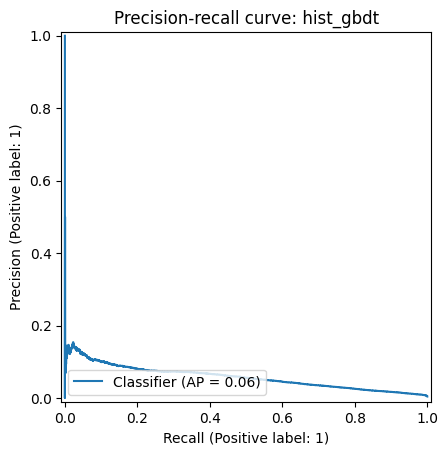

In [46]:
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title(f"Confusion matrix: {best_model_name}")
plt.show()

RocCurveDisplay.from_predictions(y_test, test_score)
plt.title(f"ROC curve: {best_model_name}")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, test_score)
plt.title(f"Precision-recall curve: {best_model_name}")
plt.show()


## 12. Permutation importance

This can be slow, so it uses at most `30_000` validation rows.


,feature,importance_mean,importance_std
3,fullmove_number,0.036058,0.005072
1,abs_eval_pawns,0.027524,0.007257
20,mover,0.022491,0.006294
5,eval_prev_1,0.017662,0.004370
4,game_ply_fraction,0.016707,0.004375
19,prev_own_pawn_loss_mean_10,0.010773,0.003545
13,abs_eval_change_prev_4,0.001734,0.001368
12,abs_eval_change_prev_2,0.001578,0.002108
11,abs_eval_change_prev_1,0.001497,0.005867
9,eval_change_prev_2,0.000331,0.000294


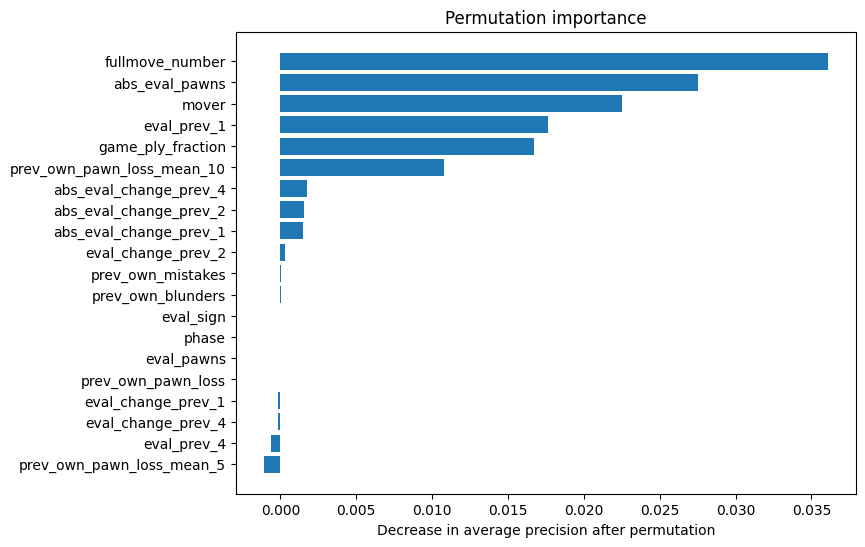

In [47]:
small_n = min(30_000, len(X_valid))

X_imp = X_valid.sample(small_n, random_state=RANDOM_STATE)
y_imp = y_valid.loc[X_imp.index]

perm = permutation_importance(
  best_model,
  X_imp,
  y_imp,
  n_repeats=5,
  scoring="average_precision",
  random_state=RANDOM_STATE,
  n_jobs=-1,
)

importance_df = pd.DataFrame({
  "feature": feature_cols,
  "importance_mean": perm.importances_mean,
  "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(importance_df)

plot_df = importance_df.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(plot_df["feature"], plot_df["importance_mean"])
ax.set_xlabel("Decrease in average precision after permutation")
ax.set_title("Permutation importance")
plt.show()


## 13. Optional XGBoost

Run this only if `xgboost` is installed in your `uv` environment.


In [48]:
try:
  from xgboost import XGBClassifier

  scale_pos_weight = y_train.eq(0).sum() / y_train.eq(1).sum()

  xgb_model = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", XGBClassifier(
      n_estimators=300,
      max_depth=4,
      learning_rate=0.04,
      subsample=0.8,
      colsample_bytree=0.8,
      objective="binary:logistic",
      eval_metric="aucpr",
      scale_pos_weight=scale_pos_weight,
      random_state=RANDOM_STATE,
      n_jobs=-1,
    )),
  ])

  xgb_model.fit(X_train, y_train)

  xgb_valid = evaluate_model(
    "xgboost",
    xgb_model,
    X_valid,
    y_valid,
  )

  display(pd.DataFrame([xgb_valid]))

except ImportError:
  print("xgboost is not installed. To add it:")
  print("uv add xgboost")


,model,roc_auc,avg_precision,balanced_acc,f1,positive_rate_pred
0,xgboost,0.927733,0.055846,0.855884,0.043281,0.162617


## 14. Suggested iteration plan

Recommended sequence:

1. `N_GAMES_SAMPLE = 5_000`, `BLUNDER_PAWN_LOSS = 1.0`
2. `N_GAMES_SAMPLE = 20_000`, `BLUNDER_PAWN_LOSS = 1.0`
3. `N_GAMES_SAMPLE = 50_000`, `BLUNDER_PAWN_LOSS = 2.0`
4. `N_GAMES_SAMPLE = 100_000`, `BLUNDER_PAWN_LOSS = 2.0`

If positives are too rare, lower `BLUNDER_PAWN_LOSS` and describe the task as
"future serious mistake prediction" rather than strict blunder prediction.
